## Categorising countries

### Data Source

The data used in this task was orginally sourced from Help.NGO. This international non-governmental organisation specialises in emergency response, preparedness, and risk mitigation.

### Dataset Attributes

- country: name of the country
- child_mort: death of children under 5 years of age per 1000 live births
- exports: exports of goods and services per capita. Given as a percentage of the GDP per capita
- health: total health spending per capita. Given as a percentage of GDP per capita
- imports: imports of goods and services per capita. Given as a percentage of the GDP per capita
- income: net income per person
- inflation: the measurement of the annual growth rate of the Total GDP
- life_expec: the average number of years a new born child would live if the current mortality patterns remain the same
- total_fer: the number of children that would be born to each woman if the current age-fertility rates remains the same
- gdpp: the GDP per capita. Calculated as the Total GDP divided by the total population.



### Objective

To group countries using socio-economic and health factors to determine the development status of the country.


In [101]:
# Import libraries
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

# Random state seed
rseed = 42

### Loading and exploring data

In [102]:
# Load and explore data
# Import the dataset
df = pd.read_csv('Country-data.csv',index_col=0)

# Check the shape
df.shape

(167, 9)

In [103]:
# Check datatypes & counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 167 entries, Afghanistan to Zambia
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   child_mort  167 non-null    float64
 1   exports     167 non-null    float64
 2   health      167 non-null    float64
 3   imports     167 non-null    float64
 4   income      167 non-null    int64  
 5   inflation   167 non-null    float64
 6   life_expec  167 non-null    float64
 7   total_fer   167 non-null    float64
 8   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 13.0+ KB


In [104]:
# Get descriptive statistics
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [105]:
# Identify any missing data
print(df.isnull().sum())

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


Preprocessing and Feature Selection

In [106]:
# Drop any non-numeric features (columns)
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


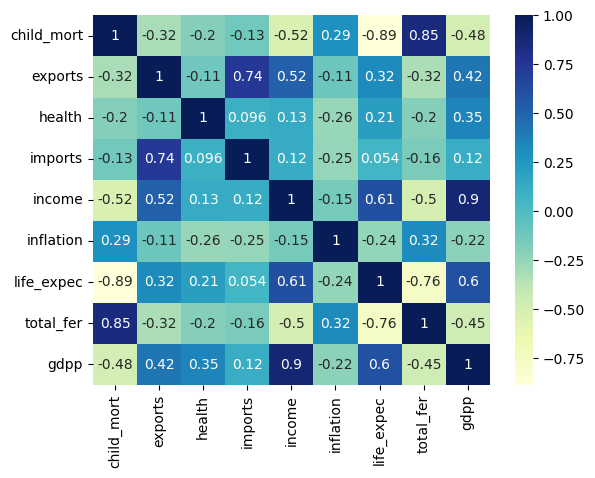

In [107]:
# Create a correlation map of features to explore relationships between features
df_n = df.select_dtypes(include=[np.int64, np.float64])
corr = df_n.corr()

sns.heatmap(corr,annot=True,cmap='YlGnBu')
plt.show()

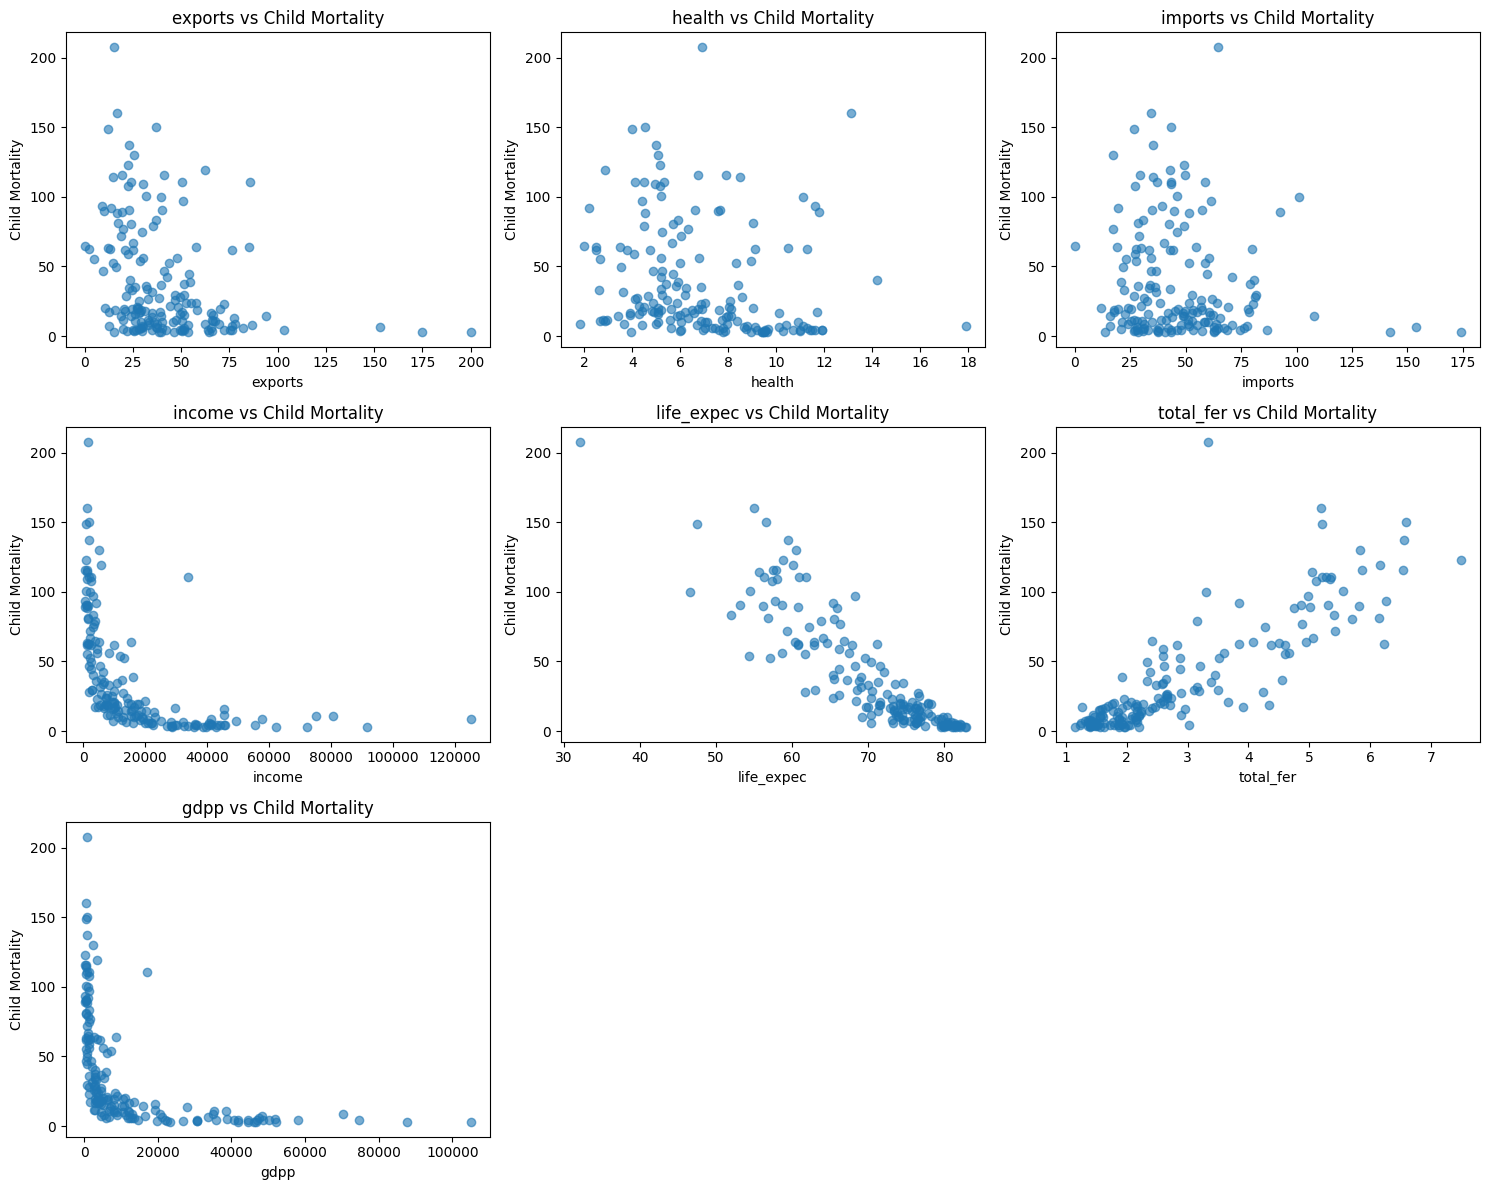

In [108]:
# Explore the continuous independent features against child_mort using scatter plots.
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

features = ['exports', 'health', 'imports', 'income', 'life_expec', 'total_fer', 'gdpp']
for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['child_mort'], alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Child Mortality')
    axes[i].set_title(f'{feature} vs Child Mortality')
    
# Hide unused subplots
for i in range(len(features), 9):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

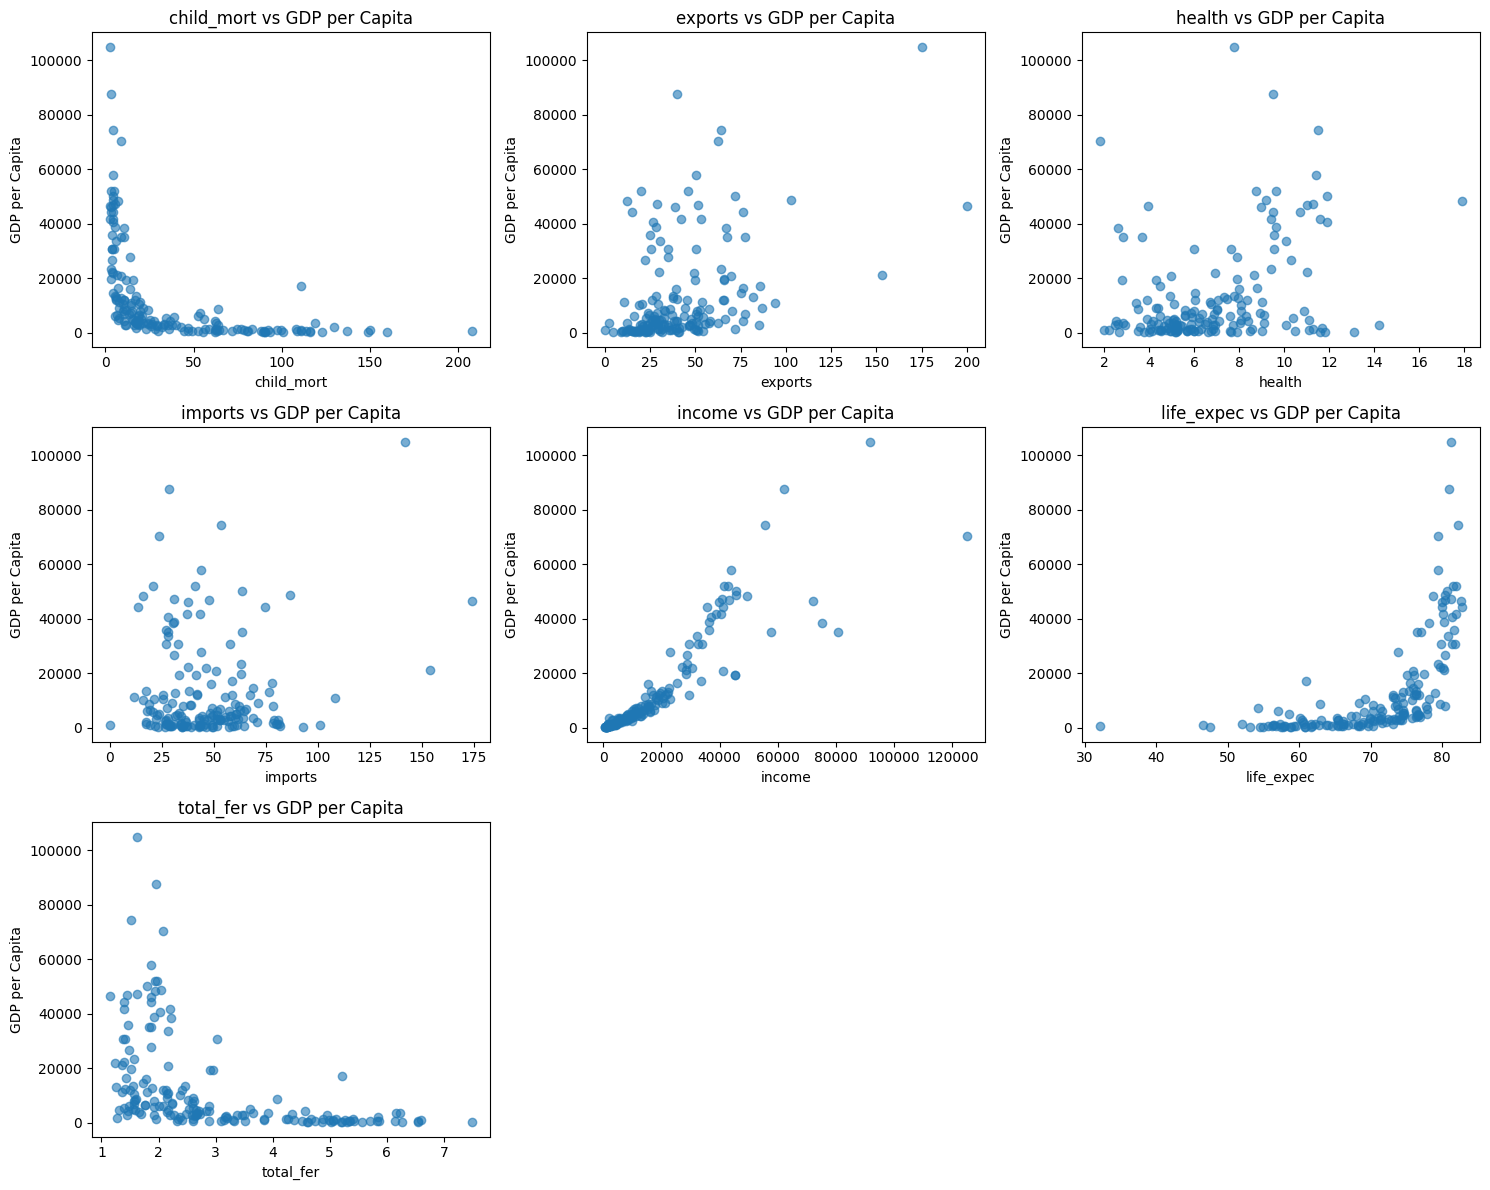

In [109]:
# Explore the continuous independent features against gdpp using scatter plots.
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

features = ['child_mort', 'exports', 'health', 'imports', 'income', 'life_expec', 'total_fer']
for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['gdpp'], alpha=0.6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('GDP per Capita')
    axes[i].set_title(f'{feature} vs GDP per Capita')
    
# Hide unused subplots
for i in range(len(features), 9):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

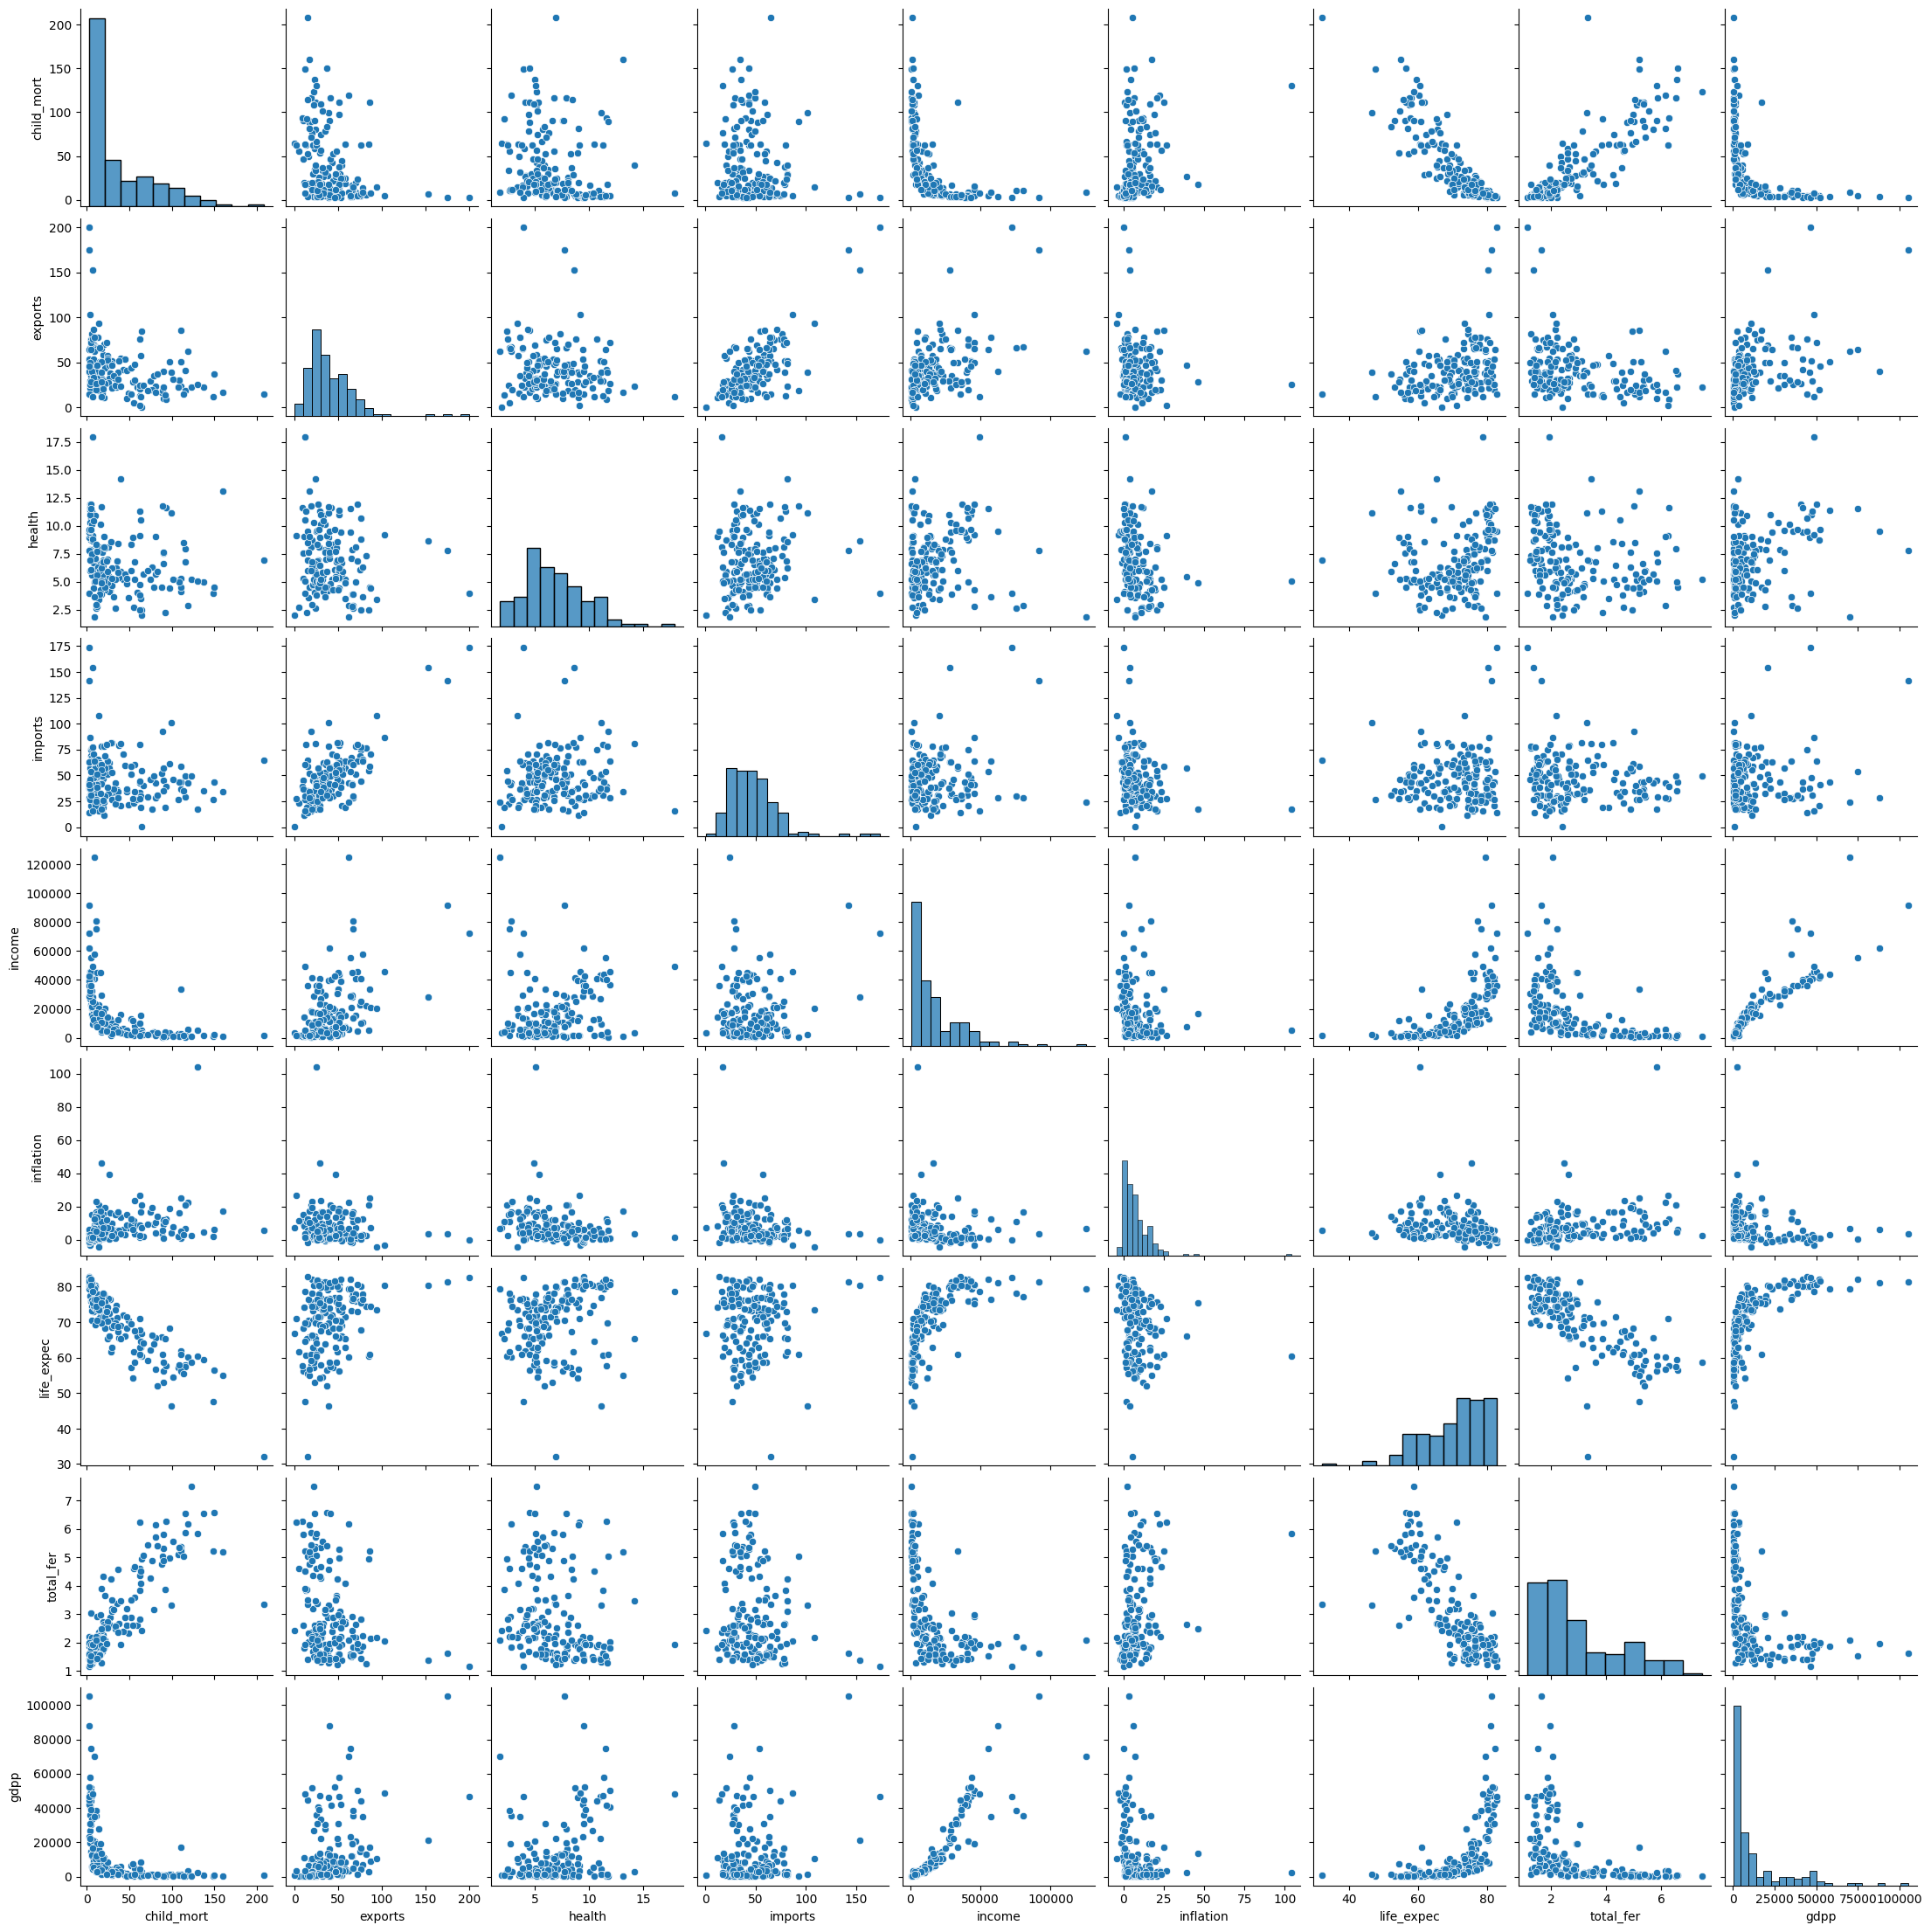

In [110]:
# Create a pair plot
sns.pairplot(df)
plt.show()

### Scaling the Data

In [111]:
# Normalise the data using MinMaxScaler
# Name the normalised dataframe "df_scaled"
scaler = MinMaxScaler()
 
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=[
  'child_mort', 'exports', 'health', 'imports', 'income', 'inflation',  'life_expec', 'total_fer', 'gdpp'],
  index=df.index)

# Check the dataframe
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
Albania,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
Algeria,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
Angola,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
Antigua and Barbuda,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


### K-Means Clustering

#### Selecting K

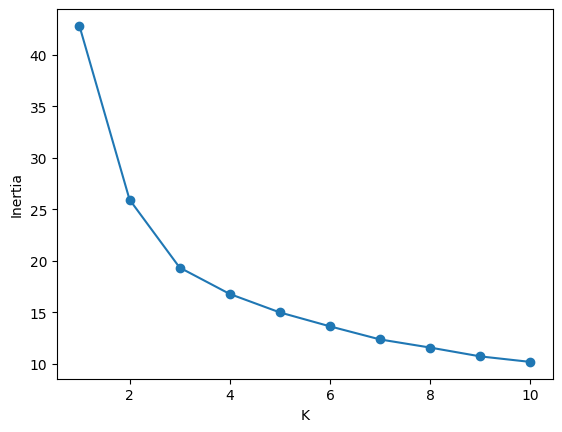

In [112]:
# Plot elbow curve
def eval_Kmeans(x, k, r):
    kmeans = KMeans(n_clusters=k, random_state=r, max_iter=500, n_init=10)
    kmeans.fit(x)
    return kmeans.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k+1)]
    plt.plot(range(1, 11), within_cluster_vars,marker='o')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.show()

# Plot elbow curve using scaled dataset
elbow_Kmeans(df_scaled)

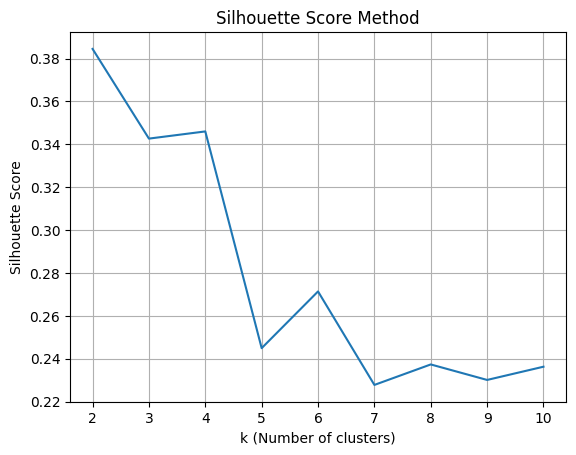

In [113]:
# Silhouette score method
kmax = 10
sil = []
plt.plot()
for k in range(2, kmax+1):
    kmeans = KMeans(n_clusters=k, random_state=rseed, max_iter=500, n_init=10)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    sil.append(silhouette_score(df_scaled, labels, metric='euclidean'))

sns.lineplot(x=range(2, kmax+1), y=sil)
plt.title('Silhouette Score Method')
plt.xlabel('k (Number of clusters)')
plt.ylabel("Silhouette Score")
plt.grid(visible=True)
plt.show()

We will choose a value for K based on the elbow and silhouette score method.

In [114]:
# Fitting a K-Means Model with the selected K value
k = 3
kmeans = KMeans(n_clusters=k, random_state=rseed, n_init=10)
kmeans.fit(df_scaled)
labels = kmeans.labels_

# Count the number of records in each cluster
df_scaled['Cluster records'] = kmeans.labels_
df_scaled['Cluster records'].value_counts()

Cluster records
2    87
1    46
0    34
Name: count, dtype: int64

In [115]:
# Display cluster characteristics in original scale for interpretation
df['Cluster'] = labels
cluster_characteristics = df.groupby('Cluster').mean()

print("Cluster characteristics (original scale):")
print("\nKey metrics by cluster:")
print("="*60)
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(f"  Number of countries: {len(cluster_data)}")
    print(f"  Avg Child Mortality: {cluster_data['child_mort'].mean():.1f} per 1000")
    print(f"  Avg GDP per capita: ${cluster_data['gdpp'].mean():,.0f}")
    print(f"  Avg Income: ${cluster_data['income'].mean():,.0f}")
    print(f"  Avg Life Expectancy: {cluster_data['life_expec'].mean():.1f} years")
    print(f"  Sample countries: {', '.join(cluster_data.index[:3].tolist())}")

Cluster characteristics (original scale):

Key metrics by cluster:

Cluster 0:
  Number of countries: 34
  Avg Child Mortality: 4.8 per 1000
  Avg GDP per capita: $43,897
  Avg Income: $46,409
  Avg Life Expectancy: 80.4 years
  Sample countries: Australia, Austria, Belgium

Cluster 1:
  Number of countries: 46
  Avg Child Mortality: 93.3 per 1000
  Avg GDP per capita: $1,696
  Avg Income: $3,517
  Avg Life Expectancy: 59.4 years
  Sample countries: Afghanistan, Angola, Benin

Cluster 2:
  Number of countries: 87
  Avg Child Mortality: 22.2 per 1000
  Avg GDP per capita: $6,833
  Avg Income: $12,914
  Avg Life Expectancy: 72.6 years
  Sample countries: Albania, Algeria, Antigua and Barbuda


In [116]:
# Display the average values for each of the features for each cluster
kmeans.cluster_centers_

array([[0.01088264, 0.28914199, 0.44196249, 0.29131375, 0.36819242,
        0.0628897 , 0.95237267, 0.09468361, 0.41678415],
       [0.44150332, 0.14597042, 0.28144675, 0.24855348, 0.02337632,
        0.15069832, 0.5383329 , 0.62148539, 0.01398231],
       [0.0956586 , 0.20354231, 0.27564776, 0.27148825, 0.09891936,
        0.1084663 , 0.79913396, 0.1787592 , 0.06301822]])

In [117]:
# Display each cluster's features average values
df_scaled.groupby('Cluster records').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster records,,,,,,,,,
0,0.010883,0.289142,0.441962,0.291314,0.368192,0.062890,0.952373,0.094684,0.416784
1,0.441503,0.145970,0.281447,0.248553,0.023376,0.150698,0.538333,0.621485,0.013982
2,0.095659,0.203542,0.275648,0.271488,0.098919,0.108466,0.799134,0.178759,0.063018


In [118]:
# Name each cluster group
cluster_names = {
    0: 'Developed',
    1: 'Least Developed',
    2: 'Developing'
}

# Assign the names to the 'Cluster' column
df_scaled['Cluster records'] = df_scaled['Cluster records'].map(cluster_names)

# Check scaled dataframe columns list
df_scaled.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'Cluster records'],
      dtype='object')

In [119]:
# Display the dataframe
df.head(80)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
country,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,1
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,2
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,2
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...
Italy,4.0,25.2,9.53,27.2,36200,0.319,81.7,1.46,35800,0
Jamaica,18.1,31.3,4.81,49.6,8000,9.810,74.7,2.17,4680,2
Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500,0


In [120]:

# Verify the model performance with silhouette coefficient
silhouette_avg = silhouette_score(df_scaled.drop('Cluster records', axis=1), labels)
print(f"Silhouette score: {silhouette_avg:.3f}")


Silhouette score: 0.343


In [121]:
# Map cluster numbers (0,1,2) to descriptive development categories
cluster_names = ['Developed', 'Least Developed', 'Developing']
descriptive_labels = [cluster_names[label] for label in labels]

### Visualization and Interpretation

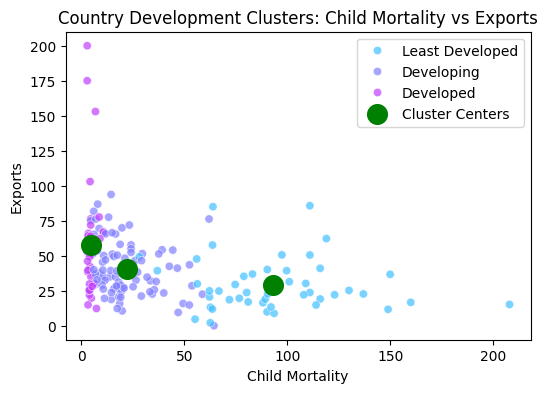

In [122]:
# Set the image size
plt.figure(figsize=(6, 4))

# Use seaborn for automatic coloring
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 1], hue=descriptive_labels, palette='cool', alpha=0.7)

# Plot cluster centers (transformed back to original scale)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 0], centers_original[:, 1], 
            marker='o', s=200, linewidths=1, color='green', label='Cluster Centers')

plt.xlabel('Child Mortality')
plt.ylabel('Exports')
plt.title('Country Development Clusters: Child Mortality vs Exports')
plt.legend()
plt.show()


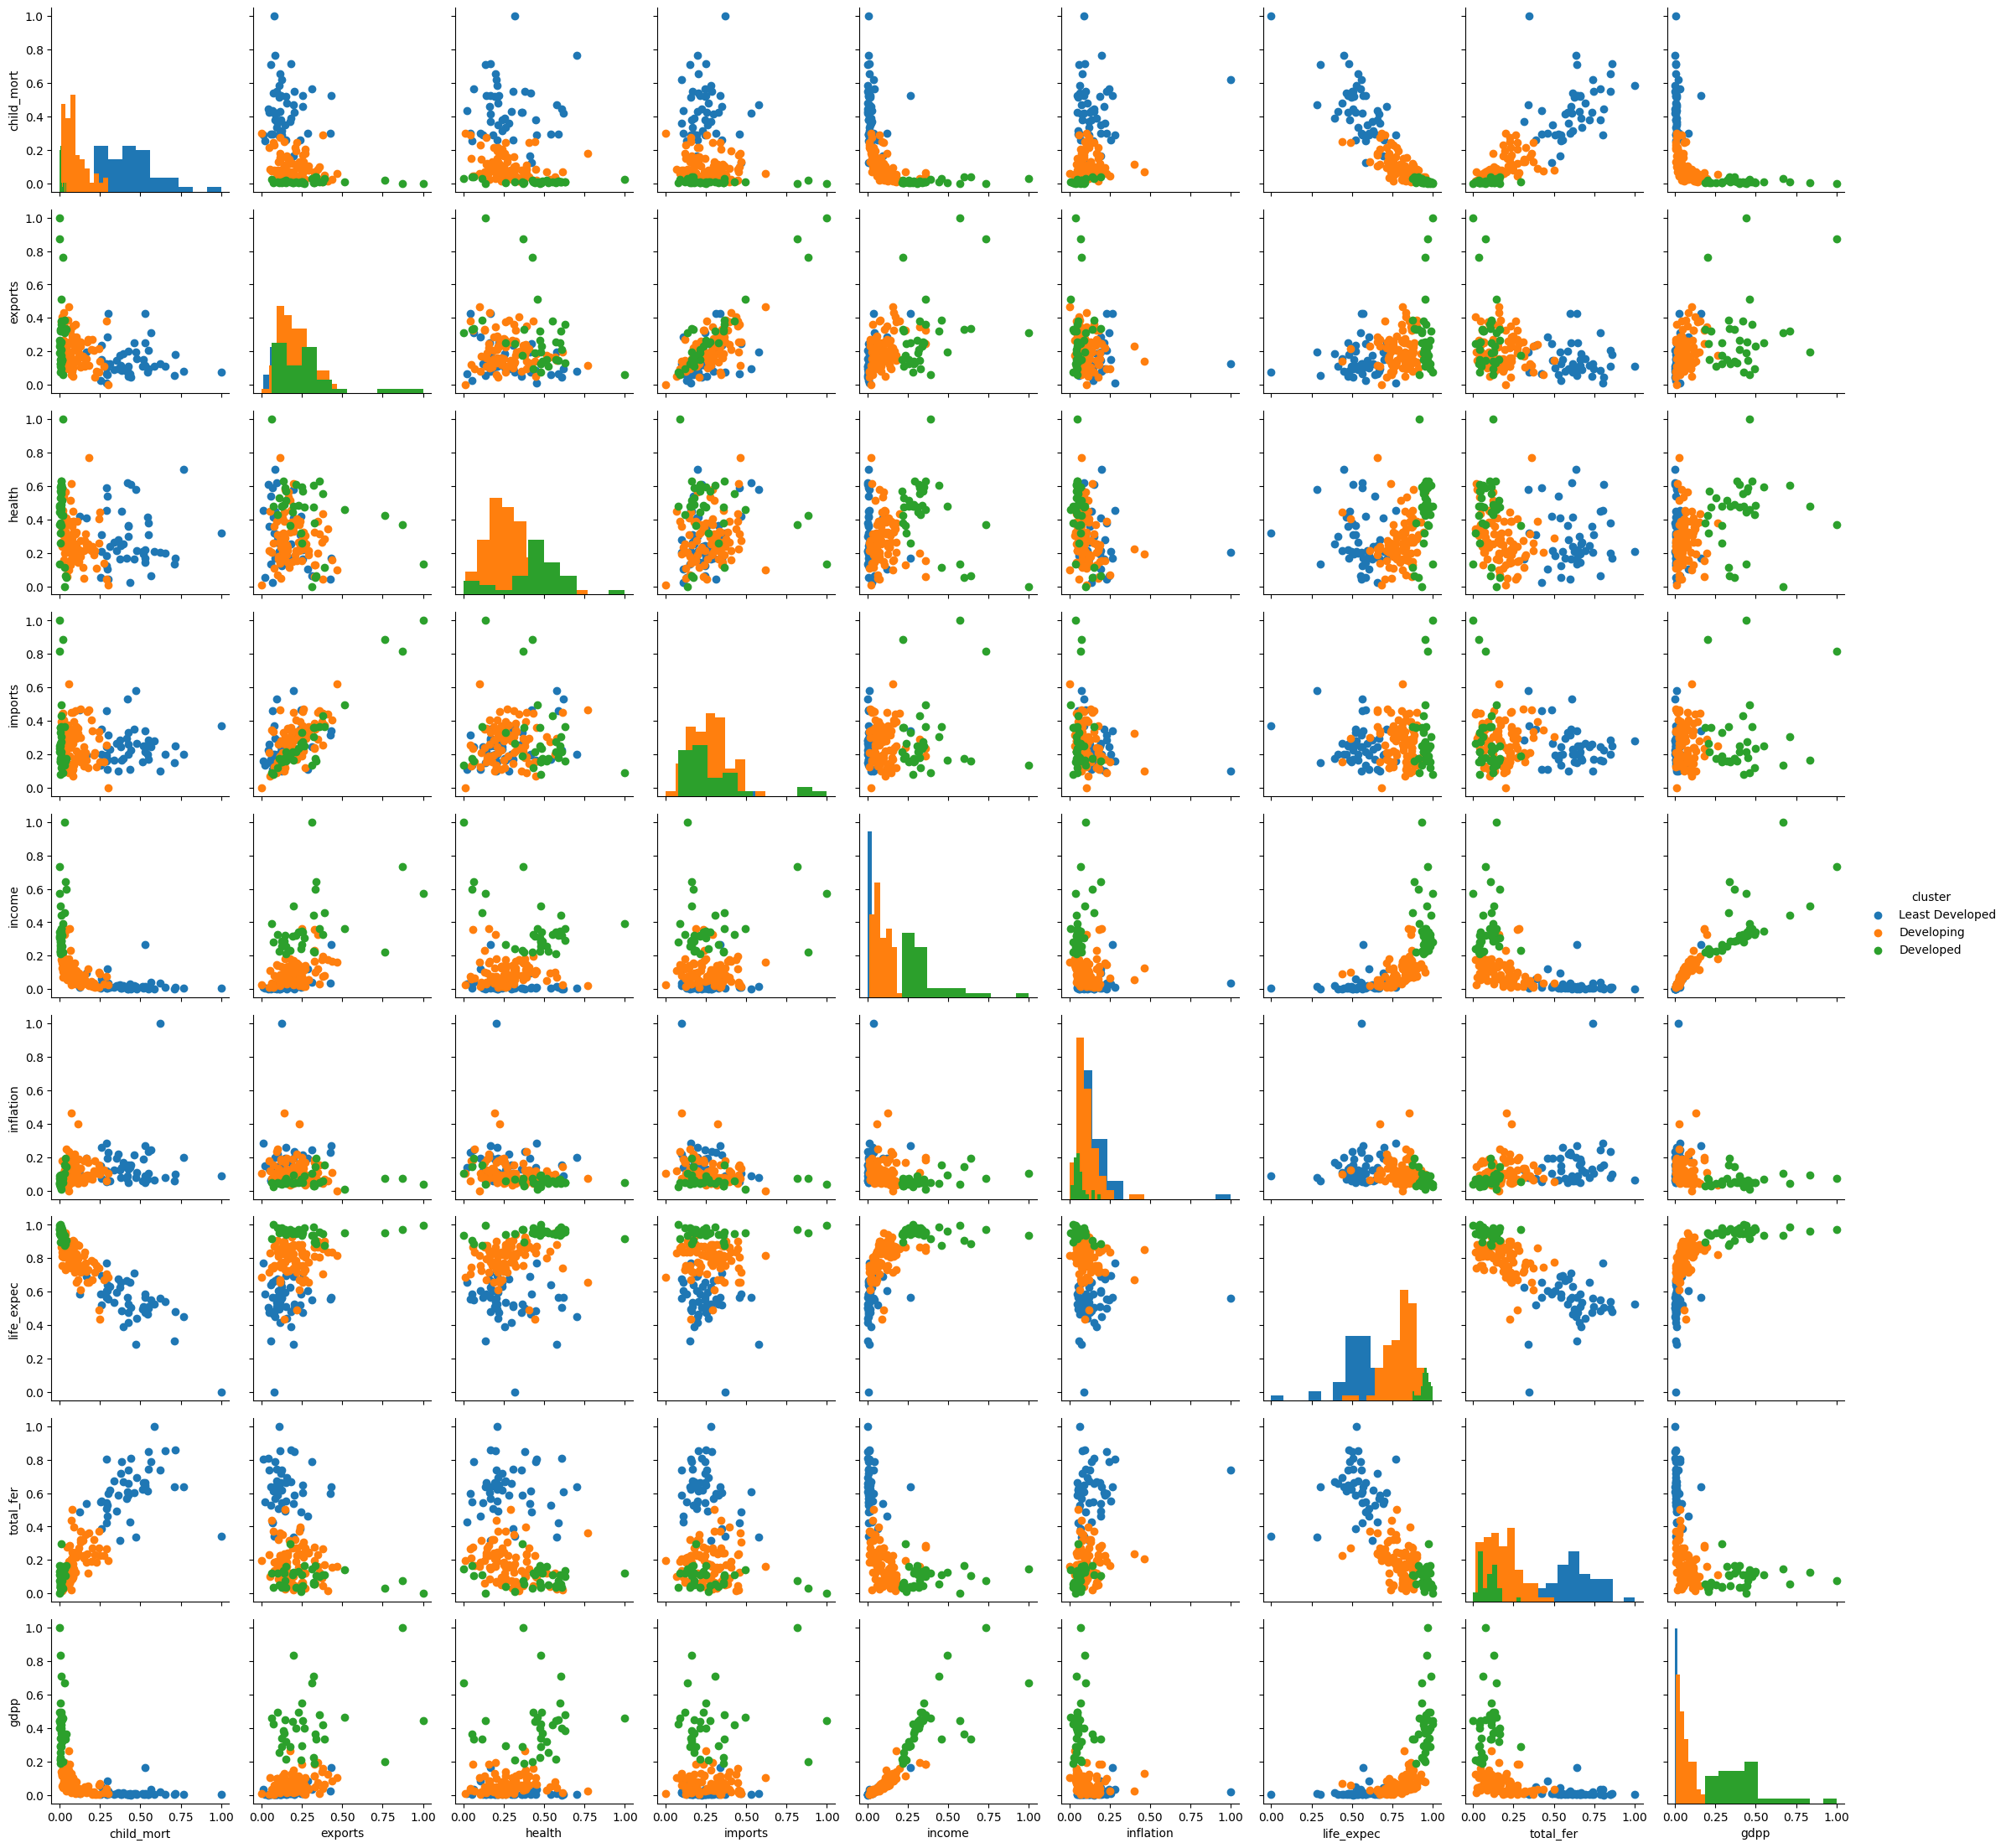

In [123]:
# Create a copy of the DataFrame with the cluster labels
df_clusters = df_scaled.copy()
df_clusters['cluster'] = descriptive_labels

# Pairplot with cluster labels
grid_cluster = sns.PairGrid(df_clusters, hue='cluster')
grid_cluster.map_diag(plt.hist)
grid_cluster.map_offdiag(plt.scatter)
grid_cluster.add_legend()
plt.show()

### Predictions

In [124]:
# Add the predicted cluster label column to the original dataframe
df['Cluster records'] = kmeans.labels_

# Display the dataframe
df.head(80)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,Cluster records
country,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,1,1
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,2,2
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,2,2
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1,1
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,2,2
...,...,...,...,...,...,...,...,...,...,...,...
Italy,4.0,25.2,9.53,27.2,36200,0.319,81.7,1.46,35800,0,0
Jamaica,18.1,31.3,4.81,49.6,8000,9.810,74.7,2.17,4680,2,2
Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500,0,0


### Visualisation of clusters

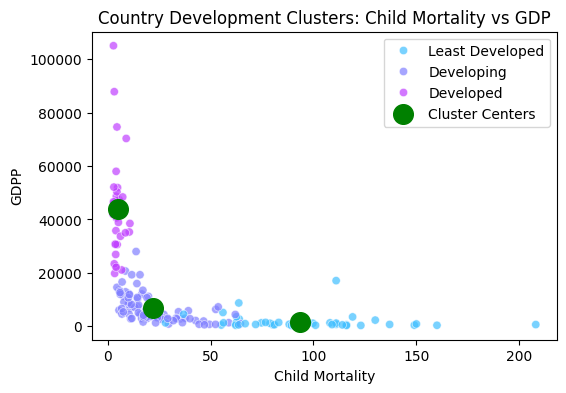

In [125]:
# Visualisation of clusters: child mortality vs gdpp

# Set image size
plt.figure(figsize=(6, 4))

# Use seaborn for automatic coloring
sns.scatterplot(x=df.iloc[:, 0], y=df.iloc[:, 8], hue=descriptive_labels, palette='cool', alpha=0.7)

# Transform cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot cluster centers in green
plt.scatter(centers_original[:, 0], centers_original[:, 8],
            marker='o', s=200, linewidths=1, color='green', label='Cluster Centers')

plt.xlabel('Child Mortality')
plt.ylabel('GDPP')
plt.title('Country Development Clusters: Child Mortality vs GDP')
plt.legend()
plt.show()


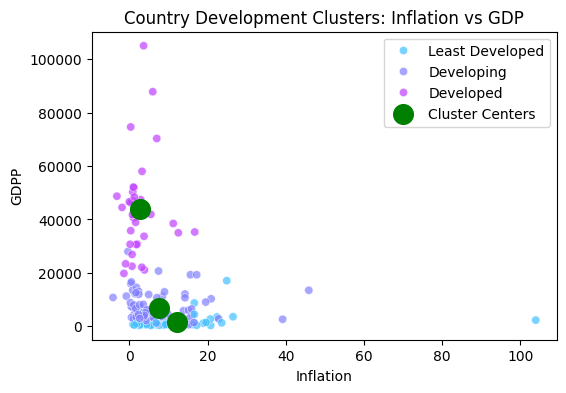

In [126]:
# Visualisation of clusters: inflation vs gdpp

# Set image size
plt.figure(figsize=(6, 4))

# Use seaborn for automatic coloring
sns.scatterplot(x=df.iloc[:, 5], y=df.iloc[:, 8], hue=descriptive_labels, palette='cool', alpha=0.7)

# Transform cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot cluster centers in green
plt.scatter(centers_original[:, 5], centers_original[:, 8],
            marker='o', s=200, linewidths=1, color='green', label='Cluster Centers')

plt.xlabel('Inflation')
plt.ylabel('GDPP')
plt.title('Country Development Clusters: Inflation vs GDP')
plt.legend()
plt.show()


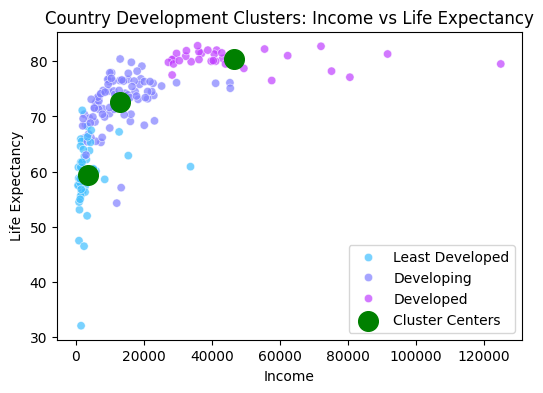

In [127]:
# Visualisation of clusters: income vs life expectancy

# Set image size
plt.figure(figsize=(6, 4))

# Use seaborn for automatic coloring
sns.scatterplot(x=df.iloc[:, 4], y=df.iloc[:, 6], hue=descriptive_labels, palette='cool', alpha=0.7)

# Transform cluster centers back to original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

# Plot cluster centers in green
plt.scatter(centers_original[:, 4], centers_original[:, 6],
            marker='o', s=200, linewidths=1, color='green', label='Cluster Centers')

plt.xlabel('Income')
plt.ylabel('Life Expectancy')
plt.title('Country Development Clusters: Income vs Life Expectancy')
plt.legend()
plt.show()


### CLUSTER INTERPRETATION

Based on comprehensive analysis of child mortality, GDP, inflation, income, and life expectancy across 167 countries:

##### Least Developed Countries

- **46 countries** (27.5% of total dataset)
- **Critical child mortality**: 93.3 per 1000 live births
- **Low economic development**:
  - GDP per capita: \$1,696
  - Income per person: \$3,517
- **Challenging health conditions**:
  - Life expectancy: 59.4 years
  - Health spending: 6.3% of GDP
- **Economic instability**: High inflation (12.1%)
- **High fertility rate**: 5.1 children per woman
- **Representative countries**: Afghanistan, Angola, Benin, Burkina Faso, Uganda, Zambia

##### Developing Countries

- **87 countries** (52.1% of total dataset - majority)
- **Moderate child mortality**: 22.2 per 1000 live births
- **Growing economies**:
  - GDP per capita: \$6,833
  - Income per person: \$12,914
- **Improving health outcomes**:
  - Life expectancy: 72.6 years
  - Health spending: 6.2% of GDP
- **Economic transition**: Variable inflation (7.5%)
- **Moderate fertility rate**: 2.3 children per woman
- **Representative countries**: Albania, Algeria, Argentina, Brazil, Colombia, Vietnam

##### Developed Countries

- **34 countries** (20.4% of total dataset)
- **Very low child mortality**: 4.8 per 1000 live births
- **High economic indicators**:
  - GDP per capita: \$43,897
  - Income per person: \$46,409
- **Excellent health outcomes**:
  - Life expectancy: 80.4 years
  - Health spending: 8.9% of GDP
- **Stable economy**: Low inflation (2.6%)
- **Low fertility rate**: 1.8 children per woman
- **Representative countries**: Australia, Austria, Belgium, United States, United Kingdom, Switzerland

---

### KEY INSIGHTS

#### Economic-Health Relationships

- Strong positive correlation between income and life expectancy across all development levels
- Child mortality shows the strongest inverse relationship with economic development
- Health spending increases with development level (6.3% → 6.2% → 8.9% of GDP)

#### Development Distribution

- Developing countries form the largest group (52.1%), indicating many nations in transition
- Developed nations are the smallest group (20.4%) but show the highest economic indicators
- Substantial gap between least developed and developing countries across all metrics

#### Model Performance

- **Silhouette Score**: 0.343 indicates fair separation between clusters
- Clear progression from least developed to developed across all socioeconomic indicators
- Strong cluster coherence with real-world development categories
